Plot the Cl vs time for unsteady simulation for 4 meshes

Mesh     55,222  σ = 0.0003
Mesh    199,560  σ = 0.0002
Mesh    765,960  σ = 0.0009
Mesh  1,515,828  σ = 0.0005


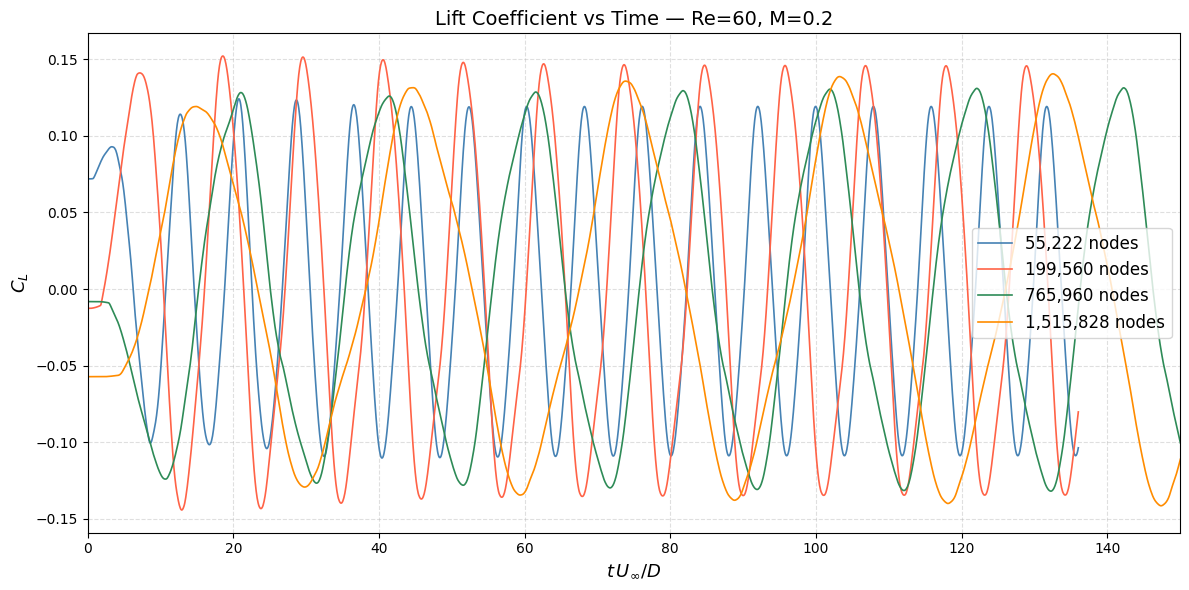

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from pyau3d.files import TopFile, PartFile
from pyau3d.utils import PltFileUtils, NodFileUtils, AnimSmartStream, GrpFileUtils
from pyau3d.constants import Constants
import pyvista as pv

# %matplotlib widget

# ── Parameters ─────────────────────────────────────────────────────────────────
RE           = 60
MACH         = 0.2
mesh_ver     = 3
GROUP        = 2
frame_rate   = 10
start        = 1
interval     = 1

U_inf        = 34.02626486 * 2   # m/s
rho_inf      = 1.60e-05          # kg/m³
span         = 0.1                        # span (m)
D            = 1
surface_area = span * D            # D × span = 1×1 m²

mesh_list = [55222, 199560, 765960, 1515828]
# mesh_list = [765960] #, 1515828]
colors    = ['steelblue', 'tomato', 'seagreen', 'darkorange']
base_dir  = f"/home/ahf25/CFD_2d_cylinder_all/Unsteady/M{MACH}/v{mesh_ver}_mesh"

# ── Area normals helper ────────────────────────────────────────────────────────
def area_normals_pv(coord, ifac3=None, ifac4=None):
    face_blocks = []
    nfac3 = 0
    if ifac3 is not None and len(ifac3) > 0:
        ifac3 = np.asarray(ifac3);  nfac3 = len(ifac3)
        face_blocks.append(np.hstack([np.full((nfac3, 1), 3), ifac3]))
    if ifac4 is not None and len(ifac4) > 0:
        ifac4 = np.asarray(ifac4);  nfac4 = len(ifac4)
        face_blocks.append(np.hstack([np.full((nfac4, 1), 4), ifac4]))
    if not face_blocks:
        raise ValueError("At least one of ifac3 or ifac4 must be provided.")
    faces = np.vstack(face_blocks).flatten()
    pdata = pv.PolyData(coord, faces)
    pdata = pdata.compute_cell_sizes(length=False, volume=False)
    face_areas  = pdata['Area']
    points_area = np.zeros(len(coord))
    if ifac3 is not None and len(ifac3) > 0:
        np.add.at(points_area, ifac3, face_areas[:nfac3, np.newaxis] / 3.0)
    if ifac4 is not None and len(ifac4) > 0:
        np.add.at(points_area, ifac4, face_areas[nfac3:, np.newaxis] / 4.0)
    pdata['anor'] = -pdata.point_normals * points_area[:, np.newaxis]
    return pdata

# ── CL extraction helper ───────────────────────────────────────────────────────
def extract_cl(mesh):
    cfd_dir = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}_unsteady"

    grp      = GrpFileUtils(f"{cfd_dir}/cylinder.grp{GROUP:02}", GROUP)
    nod      = NodFileUtils(f"{cfd_dir}/cylinder.nod")
    top      = TopFile(f"{cfd_dir}/cylinder.top")
    part     = PartFile(f"{cfd_dir}/cylinder.part")
    anim     = AnimSmartStream(f"{cfd_dir}/cylinder.an{GROUP:02}",
                               anim_vars=nod.ivars[GROUP - 1],
                               part=part, grp=grp)

    blade       = area_normals_pv(grp.coords, grp.icon3, grp.icon4)
    deltat      = top["dtstr"] / Constants()["u"]
    deltat_frame = deltat * frame_rate

    locp      = np.searchsorted(nod.ivars[GROUP - 1], 9)
    variables = np.arange(nod.nvars[GROUP - 1])
    frames    = np.arange(start, anim.nframes, interval)

    force = []
    for frame in frames:
        data      = anim.read_frame(frame, variables)
        blade['p'] = data[:, locp] * 10000
        blade['F'] = blade['p'] * np.dot(blade['anor'], [0, 1, 0])
        force.append(np.sum(blade['F']))

    force = np.array(force)
    t     = frames * deltat_frame
    CL    = force / (0.5 * rho_inf * U_inf**2 * surface_area)
    t_nd  = t * U_inf / D        # nondimensional time t·V∞/D

    return t_nd, CL

# ── Plot CL vs nondimensional time for all 4 meshes ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for mesh, color in zip(mesh_list, colors):
    try:
        t_nd, CL = extract_cl(mesh)
        ax.plot(t_nd, CL, color=color, linewidth=1.2, label=f'{mesh:,} nodes')

        # growth rate via Hilbert envelope
        analytic  = hilbert(CL - np.mean(CL))
        envelope  = np.abs(analytic)
        coeffs    = np.polyfit(t_nd, np.log(envelope + 1e-30), deg=1)
        print(f"Mesh {mesh:>10,}  σ = {coeffs[0]:.4f}")

    except FileNotFoundError:
        print(f"Skipping mesh {mesh}: files not found")

ax.set_xlabel(r'$t\,U_\infty / D$', fontsize=13)
ax.set_ylabel(r'$C_L$', fontsize=13)
ax.set_title(rf'Lift Coefficient vs Time — Re={RE}, M={MACH}', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0,150])
plt.tight_layout()
plt.savefig(f"cl_vs_time_Re{RE}_M{MACH}_mesh_convergence.png", dpi=150)
plt.show()

Plot strohaul number of the 4 meshes, with 1st and 2nd order time schemes and delta_t = 1e-4s and delta_t = 1e-5s

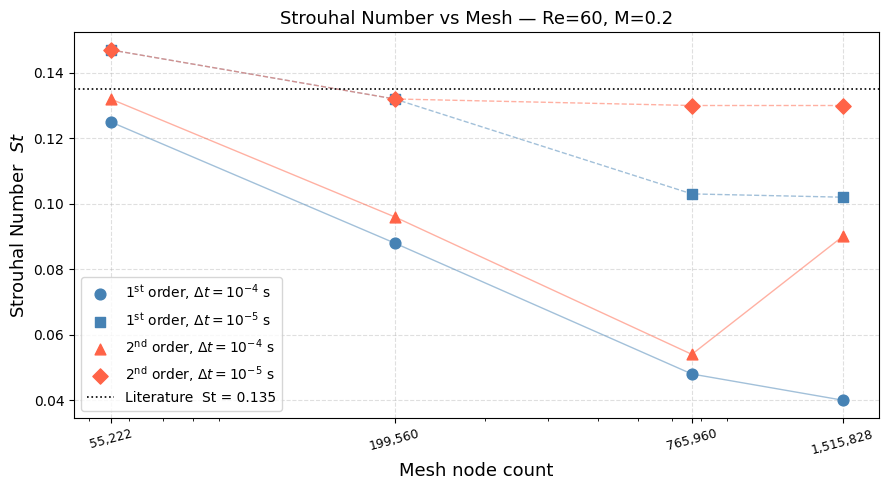

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── Mesh node counts ──────────────────────────────────────────────────────────
meshes = np.array([55222, 199560, 765960, 1515828])

# ── Strouhal number data  (NaN = not yet available → replaced with placeholder)
# TODO: replace placeholder values (marked with #!) with real data
data = {
    r'1$^\mathrm{st}$ order, $\Delta t=10^{-4}$ s': {
        'St':     [0.125, 0.088, 0.048, 0.04 ],  #! last 1 placeholder
        'color':  'steelblue',
        'marker': 'o',
    },
    r'1$^\mathrm{st}$ order, $\Delta t=10^{-5}$ s': {
        'St':     [0.147, 0.132, 0.103,  0.102 ],  #! last 1 placeholder
        'color':  'steelblue',
        'marker': 's',
        'ls':     '--',
    },
    r'2$^\mathrm{nd}$ order, $\Delta t=10^{-4}$ s': {
        'St':     [0.132, 0.096, 0.054,  0.090 ],  #! last 2 placeholder
        'color':  'tomato',
        'marker': '^',
    },
    r'2$^\mathrm{nd}$ order, $\Delta t=10^{-5}$ s': {
        'St':     [0.147, 0.132, 0.130, 0.130 ],  #! last 2 placeholder
        'color':  'tomato',
        'marker': 'D',
        'ls':     '--',
    },
}

literature_St = 0.135   # Re=60 cylinder reference

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for label, d in data.items():
    ax.scatter(meshes, d['St'],
               color=d['color'], marker=d['marker'],
               s=60, zorder=4, label=label)
    ax.plot(meshes, d['St'],
            color=d['color'], linewidth=1.0,
            linestyle=d.get('ls', '-'), alpha=0.5)

ax.axhline(literature_St, color='black', linestyle=':', linewidth=1.2,
           label=f'Literature  St = {literature_St}')

ax.set_xscale('log')
ax.set_xlabel('Mesh node count', fontsize=13)
ax.set_ylabel('Strouhal Number  $St$', fontsize=13)
ax.set_title(rf'Strouhal Number vs Mesh — Re={RE:.0f}, M={MACH}', fontsize=13)
ax.set_xticks(meshes)
ax.set_xticklabels([f'{m:,}' for m in meshes], rotation=15, fontsize=9)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f"St_vs_mesh_Re{RE:.0f}_M{MACH}.png", dpi=150)
plt.show()

Plot the frequency spectrum of the Cl profile of 4 meshes as well 